In [81]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans, MiniBatchKMeans
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Introduction
In this Jypiter notebook, we search for optimal hyperparameters for training and train the clustering models. We have a baseline infomation that the data consists of 5 categories and subsequently of 5 clusters: 
- normal
- dos
- r2l
- u2r
- probing

All other categories except `normal` are different types of attacks.

In our choice we have DBSCAN and KMeans algorithms to train model. To choose the best model we will use Siloutte Score, David-Bouldin Index and for addtional confidence -- Calinski-Harabasz Index

### Import the data
In this section we import data and analyze its contents. Specifically number of records in each category defines earlier. Mapping is done based on a specification provided in [README.md](../../README.md). As you can see below, the number of `u2r` attacks is disproportioanlly smaller than the rest of categories. Though we can see that dataset is dominated by `dos` and `normal` connections which is reasonable, considering the nature of DDOS-attack -- multiple connections overload and just general normal Internet traffic.

***Conclusion: quantities of records between different network categories is disproportioanl.***


In [82]:
data_dir = Path("../data")
silver_dir = data_dir / "silver"

In [83]:
labeled_train_data = pd.read_csv(silver_dir / "train_data.csv")

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    labeled_train_data[col] = le.fit_transform(labeled_train_data[col])

train_data = labeled_train_data.drop(columns=['attack_type', 'connection_type'])

display(train_data.head())

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,1,22,9,181,5450,0,0,0,0,...,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0
1,0,1,22,9,239,486,0,0,0,0,...,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0
2,0,1,22,9,235,1337,0,0,0,0,...,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
3,0,1,22,9,219,1337,0,0,0,0,...,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
4,0,1,22,9,217,2032,0,0,0,0,...,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0


In [84]:
labeled_test_data = pd.read_csv(silver_dir / "test_data.csv")
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    labeled_test_data[col] = le.fit_transform(labeled_test_data[col])

test_data = labeled_test_data.drop(columns=['attack_type', 'connection_type'])

display(train_data.head())

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,1,22,9,181,5450,0,0,0,0,...,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0
1,0,1,22,9,239,486,0,0,0,0,...,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0
2,0,1,22,9,235,1337,0,0,0,0,...,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
3,0,1,22,9,219,1337,0,0,0,0,...,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
4,0,1,22,9,217,2032,0,0,0,0,...,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0


In [85]:
labeled_train_data.groupby('attack_type').size()

attack_type
dos       391458
normal     97278
probe       4107
r2l         1126
u2r           52
dtype: int64

In [86]:
labeled_test_data.groupby('attack_type').size()

attack_type
dos       229059
normal     60593
probe      14329
r2l         6966
u2r           82
dtype: int64

### Data transoformation
To speed up model training time and just to make it possible on local PC, we decided to use PCA reduction with standard value for required variance of 95%. The Standard Scaling **must** be used, since some features (for instance `dst_bytes`, `dst_host_name_src_port_rate` and `service`) have differnt scales of values -- `10^3` vs `10^-21` vs `10^1`

In [87]:
scaler = StandardScaler()
pca = PCA(n_components=0.95)

In [88]:
X_train = scaler.fit_transform(train_data)
X_train_reduced = pca.fit_transform(X_train)
display(X_train_reduced)

array([[-0.51308355,  0.97771224,  4.06736601, ..., -1.29026035,
        -0.1567914 ,  0.76453393],
       [-0.51506643,  0.95953429,  4.03533344, ..., -1.26833813,
        -0.1614664 ,  0.73031855],
       [-0.49538589,  0.94023223,  3.99190704, ..., -1.23740637,
        -0.16073011,  0.69062944],
       ...,
       [-0.10393274,  1.04939744,  4.6246435 , ..., -0.68288203,
        -0.15111561,  0.82329753],
       [ 0.07796747,  1.23358962,  4.62767484, ..., -0.64638014,
        -0.15627859,  0.70891244],
       [ 0.197038  ,  1.27726331,  4.61227102, ..., -0.88716207,
        -0.14761184,  0.78729659]], shape=(494021, 20))

In [89]:
X_test = scaler.transform(test_data)
X_test_reduced = pca.transform(X_test)
display(X_test_reduced)

array([[-0.75979208,  0.31208897,  2.02743934, ..., -0.12350554,
        -0.04700267, -1.46459604],
       [-0.75979208,  0.31208897,  2.02743934, ..., -0.12350554,
        -0.04700267, -1.46459604],
       [-0.75979208,  0.31208897,  2.02743934, ..., -0.12350554,
        -0.04700267, -1.46459604],
       ...,
       [-0.7378908 ,  0.30522481,  2.02291078, ..., -0.11898853,
        -0.04841877, -1.42288297],
       [-0.7338201 ,  0.30388777,  2.01738269, ..., -0.1178944 ,
        -0.04839773, -1.42129092],
       [-0.7378908 ,  0.30522481,  2.02291078, ..., -0.11898853,
        -0.04841877, -1.42288297]], shape=(311029, 20))

### Model training
Using `MinibatchKMeans` to calcualate Elbow chart and Silhouette Score and find optimal number of clausters. Then train KMeans++ model. 

In [90]:
inertia = []
scores = []

K = range(2, 11)

for k in K:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        init='k-means++',
        n_init=10,
        batch_size=4096
    )
    model.fit(X_train_reduced)
    inertia.append(model.inertia_)
    labels = model.predict(X_test_reduced)
    score = silhouette_score(X=X_test_reduced, labels=labels, sample_size=20_000, random_state=42)
    scores.append(score)

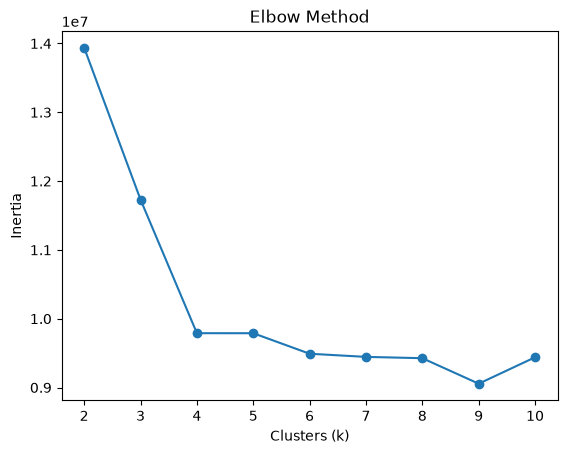

In [91]:
plt.plot(K, inertia, marker='o')
plt.xlabel("Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

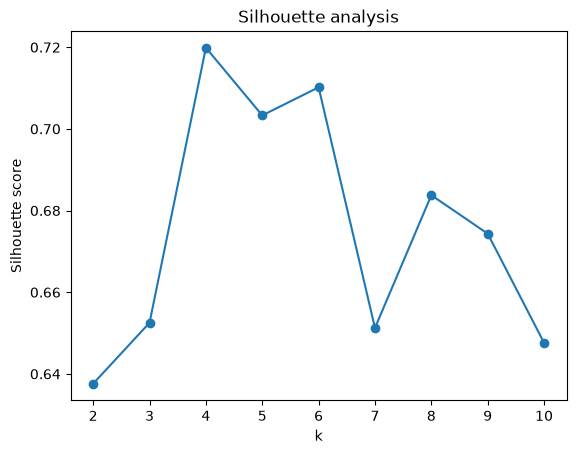

In [92]:
plt.plot(K, scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette analysis")
plt.show()

#### Traing of the KMeans with oprimal number of clusters (k=4)
The optimal number of clusters(4) does not allign with number of categories(5):
> Each connection is labeled as either:
> - normal
> - attack, with exactly one specific attack type.

And 4 different attack types:

> Attacks fall into four main categories:
> - `DOS`: denial-of-service, e.g. syn flood;
> - `R2L`: unauthorized access from a remote machine, e.g. guessing password;
> - `U2R`:  unauthorized access to local superuser (root) privileges, e.g., various `buffer overflow` attacks;
> - `probing`: surveillance and other probing, e.g., port scanning.

Sioulette Score [-1;1] and Davies-Bouldin Index [0; +inf] have values close to the optimal, which suggests that the model is good yet not overfit. High Calinski-Harabasz Index value supports this conclusion and indicates that the clusters are dense and have good separation

In [93]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

model = KMeans(
        n_clusters=4,
        random_state=42,
        init='k-means++',
        n_init=10,
    )
model.fit(X_train_reduced)

labels_pred = model.predict(X_test_reduced)
score = silhouette_score(X=X_test_reduced, labels=labels_pred, sample_size=20_000, random_state=42)
print("Silhouette Score:   ", silhouette_score(X_test_reduced, labels_pred))
print("Davies-Bouldin:     ", davies_bouldin_score(X_test_reduced, labels_pred))
print("Calinski-Harabasz:  ", calinski_harabasz_score(X_test_reduced, labels_pred))

Silhouette Score:    0.7152235620933313
Davies-Bouldin:      0.678782707232298
Calinski-Harabasz:   67507.11447060577


PCA components: 20
category     dos  normal  probe   r2l  u2r
cluster                                   
0         164078     663      3     0    0
1          17740      55    679   138    1
2          40545     123   2938   539    0
3           6696   59752  10709  6289   81


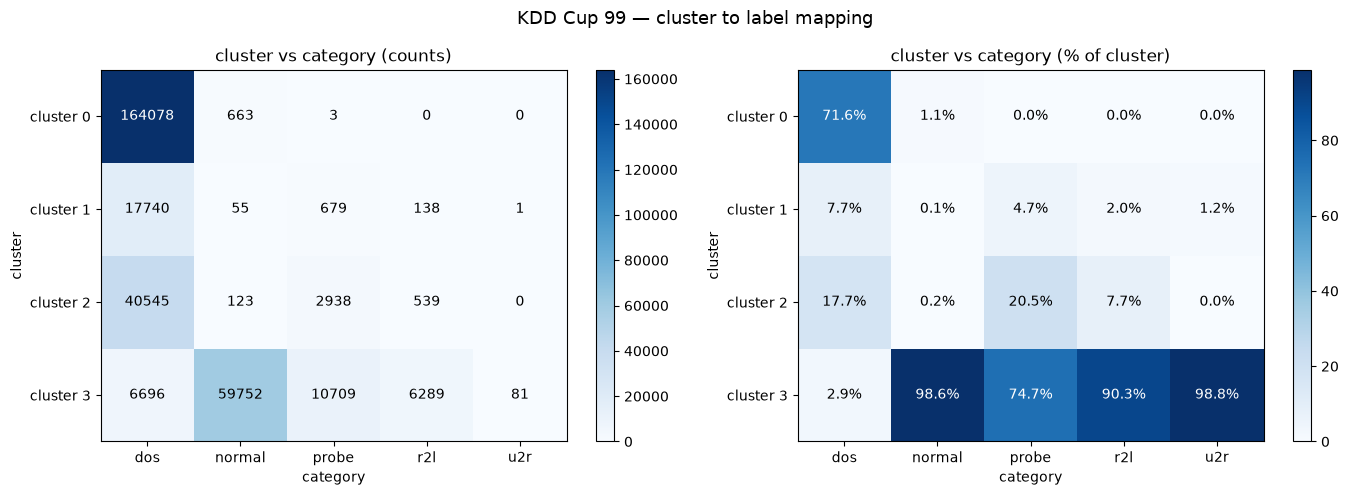

In [94]:
print("PCA components:", pca.n_components_)

viz_df = pd.DataFrame({
    'cluster': labels_pred,
    'category': labeled_test_data['attack_type'].values
})

ct = pd.crosstab(viz_df['cluster'], viz_df['category'])
print(ct)
ct_norm = ct.div(ct.sum(axis=0), axis=1) * 100

categories = ct.columns.tolist()
clusters = ct.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
    axes,
    [ct.values, ct_norm.values],
    ['{:.0f}', '{:.1f}%'],
    ['cluster vs category (counts)', 'cluster vs category (% of cluster)']
):
    im = ax.imshow(data, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(categories)))
    ax.set_yticks(range(len(clusters)))
    ax.set_xticklabels(categories)
    ax.set_yticklabels([f'cluster {c}' for c in clusters])
    ax.set_xlabel('category')
    ax.set_ylabel('cluster')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

    for i in range(len(clusters)):
        for j in range(len(categories)):
            val = data[i, j]
            text_color = 'white' if val > data.max() * 0.6 else 'black'
            ax.text(j, i, fmt.format(val), ha='center', va='center',
                    fontsize=10, color=text_color)

plt.suptitle('KDD Cup 99 — cluster to label mapping', fontsize=13)
plt.tight_layout()
plt.savefig('cluster_label_mapping.png', dpi=150, bbox_inches='tight')
plt.show()

#### KMeans(4) conclusion
As we can see, clustering identified rather 3 different almost pure clusters of DDoS attacks records(probably different subfamilies and subtype attacks). Unfortunately, due to low number of `R2L` and `U2R` attack records in datasets, the model is not able to differentiate normal traffic from R2L attacks and U2R attacks. Below is comparison of quantites of records in table form: 
| Dataset | R2L | U2R | Total |   
|---|---|---|---|
| train_data | 1126 | 52 | 494021  |  
| test_data | 5993 | 39 | 311029 |
| total | 7119 | 91 | 805050 |

Yet, if look on the matrix of clusters x known classes, we can see that the model in general filters 97% of DDoS trafic and 25.2% of Probe type attacks. Also, the clustering shows us really well, that `U2R` -- User to Root and `R2L` -- Remote-to-Local are very simillar to the normal traffic, which is also true in their core idea. Same goes with `Probe` attacks, since they are basically reconnaissance of the cyberattacks and mostly rely on initializing traffic on normal ports and known services.

#### Traing of the KMeans with known number of clusters (k=5)
The optimal number of clusters(4) does not allign with number of categories(5):
> Each connection is labeled as either:
> - normal
> - attack, with exactly one specific attack type.

And 4 different attack types:

> Attacks fall into four main categories:
> - `DOS`: denial-of-service, e.g. syn flood;
> - `R2L`: unauthorized access from a remote machine, e.g. guessing password;
> - `U2R`:  unauthorized access to local superuser (root) privileges, e.g., various `buffer overflow` attacks;
> - `probing`: surveillance and other probing, e.g., port scanning.

However, since we know the number of classes that exist in dataset we should at least try to create a clustering model that creates 5 groups.

All indexes have almost identical, maybe a little smaller values, which is logical and was predicted by Elbow Chart made based on MiniBatchKmeans classifiers.

In [95]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

model_5 = KMeans(
        n_clusters=5,
        random_state=42,
        init='k-means++',
        n_init=10,
    )
model_5.fit(X_train_reduced)

labels_pred_5 = model_5.predict(X_test_reduced)
score_5 = silhouette_score(X=X_test_reduced, labels=labels_pred_5, sample_size=20_000, random_state=42)
print("Silhouette Score:   ", silhouette_score(X_test_reduced, labels_pred_5))
print("Davies-Bouldin:     ", davies_bouldin_score(X_test_reduced, labels_pred_5))
print("Calinski-Harabasz:  ", calinski_harabasz_score(X_test_reduced, labels_pred_5))

Silhouette Score:    0.7159979659734121
Davies-Bouldin:      0.6081622301530663
Calinski-Harabasz:   61366.007417595596


PCA components: 20
category     dos  normal  probe   r2l  u2r
cluster                                   
0         164078     663      3     0    0
1          17740      55    679   138    1
2          40545     123   2938   539    0
3           6696   59752  10709  6289   81


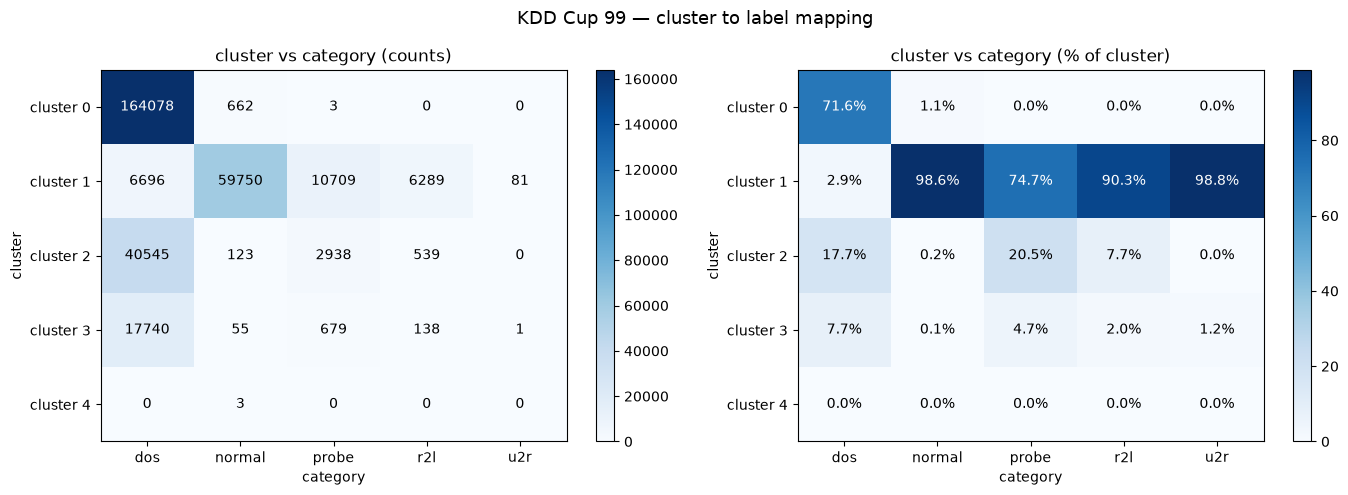

In [97]:
print("PCA components:", pca.n_components_)

viz_df_5 = pd.DataFrame({
    'cluster': labels_pred_5,
    'category': labeled_test_data['attack_type'].values
})

ct_5 = pd.crosstab(viz_df_5['cluster'], viz_df_5['category'])
print(ct)
ct_norm_5 = ct_5.div(ct_5.sum(axis=0), axis=1) * 100

categories_5 = ct_5.columns.tolist()
clusters_5 = ct_5.index.tolist()

fig_5, axes_5 = plt.subplots(1, 2, figsize=(14, 5))

for ax_5, data_5, fmt_5, title_5 in zip(
    axes_5,
    [ct_5.values, ct_norm_5.values],
    ['{:.0f}', '{:.1f}%'],
    ['cluster vs category (counts)', 'cluster vs category (% of cluster)']
):
    im_5 = ax_5.imshow(data_5, cmap='Blues', aspect='auto')
    ax_5.set_xticks(range(len(categories_5)))
    ax_5.set_yticks(range(len(clusters_5)))
    ax_5.set_xticklabels(categories_5)
    ax_5.set_yticklabels([f'cluster {c}' for c in clusters_5])
    ax_5.set_xlabel('category')
    ax_5.set_ylabel('cluster')
    ax_5.set_title(title_5)
    plt.colorbar(im_5, ax=ax_5)

    for i in range(len(clusters_5)):
        for j in range(len(categories_5)):
            val = data_5[i, j]
            text_color = 'white' if val > data_5.max() * 0.6 else 'black'
            ax_5.text(j, i, fmt_5.format(val), ha='center', va='center',
                    fontsize=10, color=text_color)

plt.suptitle('KDD Cup 99 — cluster to label mapping', fontsize=13)
plt.tight_layout()
plt.savefig('cluster_label_mappin_5.png', dpi=150, bbox_inches='tight')
plt.show()

#### KMeans(5) conclusion
Looking at the same matrix for 5 clusters, we can see that nothing has changed, only new pseudo cluster of 3 records for normal traffic category was created. In all other details -- this classifier has all the same advantages and disadvantages: good filtering of `DDoS`, some filtering of `Probe` and grouping og `R2L`, `U2R`, rest of `Probe` and `Normal` into one single cluster.

## Conclusion
Overall clustering Kmeans models were good at showing not obvious properties of and issues with data (at least to inexperienced ML Engineer).
It is a good model for filtering DDoS from traffic and for the analytics and identification of different subfamilies of attack types, however for filtering more dangerous and harmful attacks like `User-to-Root` ot `Remote-to-Local` -- more data of those attacks is needed.